In [1]:
%matplotlib notebook

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices, Alignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.estimalign import estimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

In [4]:
from sklearn.linear_model import LogisticRegression 
import pandas as pd

# Aligner and parameters

In [5]:
blosum62 = substitution_matrices.load('BLOSUM62')
blosum62 = blosum62 - np.mean(blosum62)
blosum62 /= np.sqrt(np.sum(blosum62**2))
# blosum62 *= 5
print(np.max(blosum62), np.min(blosum62))

0.23582357997516276 -0.052694648711527445


In [6]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

In [7]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'
Asize = len(alphabet)

# Data

In [8]:
human_proteome = list(SeqIO.parse('Test_protein_data/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Test_protein_data/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [9]:
human_proteome = [seq for seq in human_proteome if set(str(seq.seq)).issubset(set(alphabet))]
chick_proteome = [seq for seq in chick_proteome if set(str(seq.seq)).issubset(set(alphabet))]

In [10]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [11]:
human_prot_ids_set = set(human_prot_ids)
chick_prot_ids_set = set(chick_prot_ids)

In [12]:
human_protid_to_crd = {seq.id: i for i, seq in enumerate(human_proteome)}
chick_protid_to_crd = {seq.id: i for i, seq in enumerate(chick_proteome)}

In [13]:
positive_id_tuples = []
with open('./Test_protein_data/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue > 0.0001:
            positive_id_tuples.append((l[0], l[1]))

In [14]:
positive_id_tuples = [t for t in positive_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]

In [15]:
len(positive_id_tuples)

2696913

In [16]:
positive_id_tuples = list(set(positive_id_tuples))

In [17]:
len(positive_id_tuples)

2238760

# Alignment

In [18]:
SETSIZE = 1000000

In [20]:
pos_set = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in pos_set]

In [21]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [22]:
test_aln = [next(aligner.align(A, B)) for A,B in zip(human_list, chick_list)]

In [23]:
matches = [aln.counts().identities for aln in test_aln]
mismatches = [aln.counts().mismatches for aln in test_aln]
gaps = [aln.counts().gaps for aln in test_aln]
idperc = [aln.counts().identities/aln.counts().aligned for aln in test_aln]
gapperc = [aln.counts().gaps/aln.counts().aligned for aln in test_aln]

In [24]:
test_aln = [aln for aln, gprc in zip(test_aln, gapperc) if gprc < 0.2]

In [25]:
test_scores = np.array([aln.score for aln in test_aln])

In [26]:
true_alpha = -np.median(test_scores)
true_alpha

-1.0101219666691512

In [27]:
logit_scores = logit_partial_scores(test_scores, true_alpha)
labels = rd.rand(len(logit_scores))
labels = labels <= logit_scores

<IPython.core.display.Javascript object>


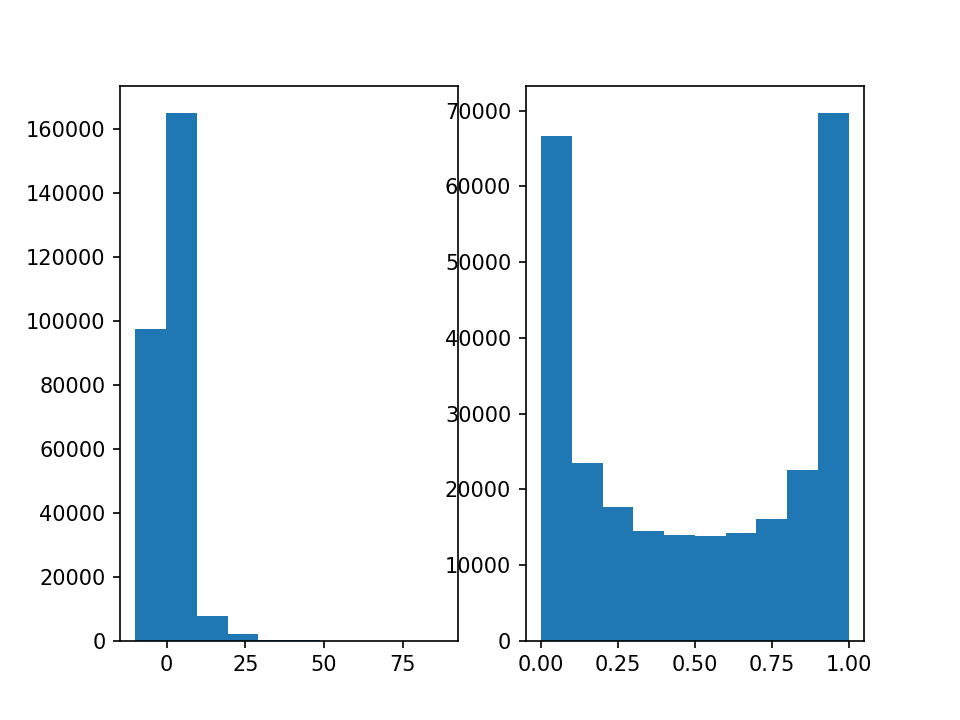

(array([66688., 23431., 17657., 14555., 14001., 13823., 14267., 16024.,
        22519., 69697.]),
 array([1.75195678e-05, 1.00015768e-01, 2.00014016e-01, 3.00012264e-01,
        4.00010512e-01, 5.00008760e-01, 6.00007008e-01, 7.00005256e-01,
        8.00003504e-01, 9.00001752e-01, 1.00000000e+00]),
 <BarContainer object of 10 artists>)

In [28]:
plt.figure()
plt.subplot(121)
plt.hist(test_scores)
plt.subplot(122)
plt.hist(logit_scores)

# Logistic regression 

In [29]:
Asize = len(alphabet)
predictors = []
pair_to_id = {(char1, char2): Asize*i + j for i, char1 in enumerate(alphabet) for j, char2 in enumerate(alphabet)}
for aln in test_aln:
    counts = aln.counts()
    gaps = [counts.open_gaps,
            counts.extend_gaps]
    substitutions = [0]*(Asize**2)
    for char1, char2 in zip(aln[0], aln[1]):
        if char1 != '-' and char2 != '-':
            substitutions[pair_to_id[(char1, char2)]] += 1
    predictors.append(substitutions+gaps)

In [30]:
data = pd.DataFrame(predictors, columns=[char1+char2 for char1 in alphabet for char2 in alphabet] + ['GapO', 'GapE'])
data

,AA,AC,AD,AE,AF,AG,AH,AI,AK,AL,...,YP,YQ,YR,YS,YT,YV,YW,YY,GapO,GapE
0,3,3,4,4,0,7,3,3,4,4,...,0,1,0,2,0,0,0,1,3,38
1,3,0,3,0,0,1,1,0,0,3,...,3,3,1,1,0,2,0,0,3,47
2,2,2,4,0,2,4,0,2,2,6,...,0,0,0,0,0,0,0,2,4,43
3,6,2,1,3,2,1,2,1,1,1,...,1,2,0,2,2,0,0,6,5,114
4,0,0,0,2,0,0,0,0,1,2,...,0,2,0,3,1,1,0,0,3,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272657,5,0,3,1,1,0,0,0,0,0,...,0,0,0,0,0,2,0,3,3,21
272658,0,3,2,2,4,2,0,2,5,8,...,0,0,0,0,1,0,1,2,6,89
272659,6,2,5,0,0,4,1,5,3,4,...,2,0,1,2,2,3,1,4,6,131
272660,1,3,0,1,1,2,0,2,0,0,...,1,0,0,1,0,1,0,2,3,57


In [31]:
logit = LogisticRegression(fit_intercept=True, solver='newton-cg',
                            max_iter=1000, penalty=None)
logit.fit(data, labels)

LogisticRegression(max_iter=1000, penalty=None, solver='newton-cg')

In [32]:
coefM = substitution_matrices.Array(data=np.zeros((Asize, Asize)), alphabet=alphabet)
for char1 in alphabet:
    for char2 in alphabet:
        coefM[char1, char2] = logit.coef_[0][pair_to_id[(char1, char2)]]

In [33]:
blosum_vs_mine = []
for char1 in alphabet:
    for char2 in alphabet:
        blosum_vs_mine.append([char1, char2,blosum62[char1, char2], coefM[char1, char2], sum(data[char1+char2])])

<IPython.core.display.Javascript object>


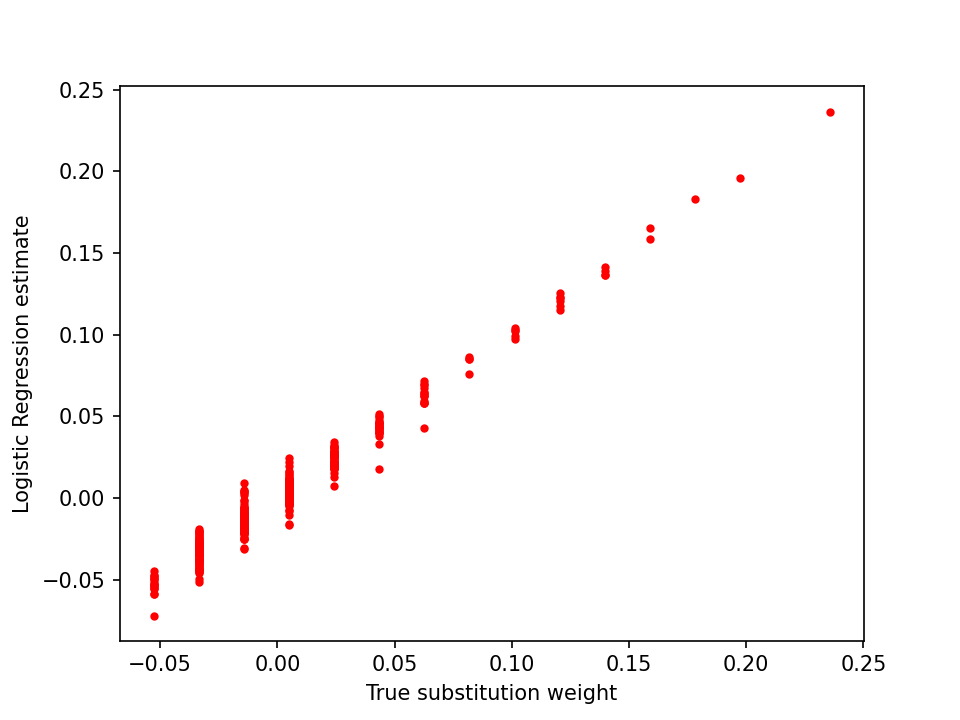

In [34]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')
plt.xlabel('True substitution weight')
plt.ylabel('Logistic Regression estimate')
plt.savefig('Figs/LogReg setsize %i.png' % SETSIZE, dpi=300)